# Week 1 Jupyter Notebook – Linear Regression 1

# DX799 Capstone Notebook

Project: Predicting and explaining 2019 U.S. flight delay risk.

Dataset setup:
- `train.csv`: Kaggle 2019 flight delay modeling data
- `test.csv`: Kaggle 2019 flight delay testing data
- `Flight_delay.csv`: BTS Airline Delay Cause data for 2019

The main modeling target is `DEP_DEL15`, where 1 means the flight departure was delayed by 15 minutes or more.

This notebook applies Week 1 topics to the flight delay dataset:
- linear regression
- polynomial terms
- interaction terms
- multicollinearity
- variance inflation factor (VIF)
- categorical and continuous features


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SAMPLE_SIZE = 100000
TEST_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (100000, 30)
Test shape: (50000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


In [25]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

print("\nTrain missing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


Target counts:
DEP_DEL15
0    81025
1    18975
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.03
1    18.98
Name: proportion, dtype: float64

Train missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


In [26]:
target = "DEP_DEL15"

base_numeric_features = [
    "MONTH", "DAY_OF_WEEK", "DISTANCE_GROUP", "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS", "NUMBER_OF_SEATS", "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH", "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT", "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS", "GROUND_SERV_PER_PASS", "PLANE_AGE",
    "LATITUDE", "LONGITUDE", "PRCP", "SNOW", "SNWD", "TMAX", "AWND",
    "CARRIER_HISTORICAL", "DEP_AIRPORT_HIST", "DAY_HISTORICAL", "DEP_BLOCK_HIST"
]

numeric_features = [col for col in base_numeric_features if col in train.columns]

print("Number of numeric features used:", len(numeric_features))
print(numeric_features)

X = train[numeric_features].copy()
y = train[target].copy()

X = X.fillna(X.median(numeric_only=True))
print("X shape:", X.shape)
print("y shape:", y.shape)


Number of numeric features used: 25
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']
X shape: (100000, 25)
y shape: (100000,)


## Simple EDA

This section looks at the target balance and a few relationships between numeric features and delay risk.

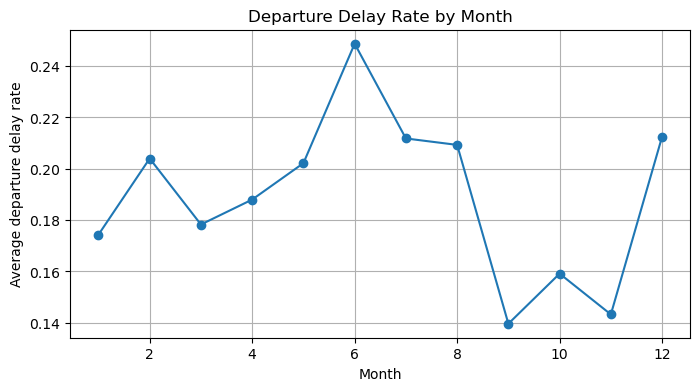

,MONTH,DEP_DEL15
0,1,0.174336
1,2,0.204017
2,3,0.178297
3,4,0.188013
4,5,0.202197
5,6,0.248743
6,7,0.211828
7,8,0.209321
8,9,0.139636
9,10,0.159148


In [27]:
delay_by_month = train.groupby("MONTH")["DEP_DEL15"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.plot(delay_by_month["MONTH"], delay_by_month["DEP_DEL15"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average departure delay rate")
plt.title("Departure Delay Rate by Month")
plt.grid(True)
plt.show()

delay_by_month


In [28]:
corr = train[numeric_features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)
print("Correlation with DEP_DEL15:")
print(corr)


Correlation with DEP_DEL15:
DEP_DEL15                        1.000000
DEP_BLOCK_HIST                   0.197496
CARRIER_HISTORICAL               0.119734
SEGMENT_NUMBER                   0.117251
DEP_AIRPORT_HIST                 0.102369
DAY_HISTORICAL                   0.096115
PRCP                             0.084387
SNOW                             0.053677
AWND                             0.050973
LONGITUDE                        0.035720
AIRPORT_FLIGHTS_MONTH            0.026335
SNWD                             0.025342
AVG_MONTHLY_PASS_AIRPORT         0.021845
DISTANCE_GROUP                   0.015258
NUMBER_OF_SEATS                  0.013168
AIRLINE_AIRPORT_FLIGHTS_MONTH    0.012566
CONCURRENT_FLIGHTS               0.010123
PLANE_AGE                        0.005302
AIRLINE_FLIGHTS_MONTH            0.001752
LATITUDE                         0.000547
DAY_OF_WEEK                      0.000250
AVG_MONTHLY_PASS_AIRLINE        -0.000226
FLT_ATTENDANTS_PER_PASS         -0.002924
TMAX  

## Baseline Linear Regression

Although `DEP_DEL15` is binary, this week focuses on linear regression concepts. I treat the target as numeric here for comparison, then use logistic regression later in Week 4.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

pred = linear_model.predict(X_val)

rmse = mean_squared_error(y_val, pred, squared=False)
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print("Baseline Linear Regression")
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))
print("R-squared:", round(r2, 4))


Baseline Linear Regression
RMSE: 0.3796
MAE: 0.2896
R-squared: 0.063


## Polynomial Terms

Polynomial terms allow a linear model to capture curved relationships. I use a small set of variables to keep the model manageable.

In [30]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

poly_features = [col for col in ["PRCP", "AWND", "CONCURRENT_FLIGHTS", "DEP_BLOCK_HIST", "CARRIER_HISTORICAL"] if col in X.columns]

X_poly = X[poly_features].copy()

X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_poly, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train_p, y_train_p)
poly_pred = poly_model.predict(X_val_p)

print("Polynomial Linear Regression")
print("Features used:", poly_features)
print("RMSE:", round(mean_squared_error(y_val_p, poly_pred, squared=False), 4))
print("MAE:", round(mean_absolute_error(y_val_p, poly_pred), 4))
print("R-squared:", round(r2_score(y_val_p, poly_pred), 4))


Polynomial Linear Regression
Features used: ['PRCP', 'AWND', 'CONCURRENT_FLIGHTS', 'DEP_BLOCK_HIST', 'CARRIER_HISTORICAL']
RMSE: 0.3796
MAE: 0.2896
R-squared: 0.0627


## Interaction Terms

Interaction terms test whether two variables work together. For example, weather may matter more during busy departure blocks or at airports with higher historical delay rates.

In [31]:
interaction_df = X.copy()

if "PRCP" in interaction_df.columns and "DEP_BLOCK_HIST" in interaction_df.columns:
    interaction_df["PRCP_x_DEP_BLOCK_HIST"] = interaction_df["PRCP"] * interaction_df["DEP_BLOCK_HIST"]

if "AWND" in interaction_df.columns and "CONCURRENT_FLIGHTS" in interaction_df.columns:
    interaction_df["AWND_x_CONCURRENT_FLIGHTS"] = interaction_df["AWND"] * interaction_df["CONCURRENT_FLIGHTS"]

if "CARRIER_HISTORICAL" in interaction_df.columns and "DEP_AIRPORT_HIST" in interaction_df.columns:
    interaction_df["CARRIER_x_AIRPORT_HIST"] = interaction_df["CARRIER_HISTORICAL"] * interaction_df["DEP_AIRPORT_HIST"]

X_train_i, X_val_i, y_train_i, y_val_i = train_test_split(
    interaction_df, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

interaction_model = LinearRegression()
interaction_model.fit(X_train_i, y_train_i)

interaction_pred = interaction_model.predict(X_val_i)

print("Linear Regression with Interaction Terms")
print("Number of features:", interaction_df.shape[1])
print("RMSE:", round(mean_squared_error(y_val_i, interaction_pred, squared=False), 4))
print("MAE:", round(mean_absolute_error(y_val_i, interaction_pred), 4))
print("R-squared:", round(r2_score(y_val_i, interaction_pred), 4))


Linear Regression with Interaction Terms
Number of features: 28
RMSE: 0.379
MAE: 0.2888
R-squared: 0.0655


## Categorical and Continuous Features

This model adds selected categorical variables using one-hot encoding.

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = [col for col in ["DEP_TIME_BLK", "CARRIER_NAME"] if col in train.columns]
continuous_features = numeric_features

X_mixed = train[continuous_features + categorical_features].copy()
X_mixed[continuous_features] = X_mixed[continuous_features].fillna(X_mixed[continuous_features].median(numeric_only=True))
for col in categorical_features:
    X_mixed[col] = X_mixed[col].fillna("Unknown")

X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_mixed, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), continuous_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

mixed_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

mixed_model.fit(X_train_m, y_train_m)
mixed_pred = mixed_model.predict(X_val_m)

print("Linear Regression with Numeric and Categorical Features")
print("Categorical features:", categorical_features)
print("RMSE:", round(mean_squared_error(y_val_m, mixed_pred, squared=False), 4))
print("MAE:", round(mean_absolute_error(y_val_m, mixed_pred), 4))
print("R-squared:", round(r2_score(y_val_m, mixed_pred), 4))


Linear Regression with Numeric and Categorical Features
Categorical features: ['DEP_TIME_BLK', 'CARRIER_NAME']
RMSE: 0.3791
MAE: 0.289
R-squared: 0.0653


## Multicollinearity and VIF

VIF is used to identify predictors that may overlap heavily with other predictors. High VIF values suggest multicollinearity.

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [col for col in [
    "CONCURRENT_FLIGHTS", "NUMBER_OF_SEATS", "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH", "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT", "AVG_MONTHLY_PASS_AIRLINE",
    "PRCP", "AWND", "CARRIER_HISTORICAL", "DEP_AIRPORT_HIST", "DEP_BLOCK_HIST"
] if col in X.columns]

vif_data = X[vif_features].copy().fillna(X[vif_features].median(numeric_only=True))

# Use a smaller sample for VIF speed
vif_sample = vif_data.sample(n=min(10000, len(vif_data)), random_state=RANDOM_STATE)

vif_results = pd.DataFrame({
    "feature": vif_sample.columns,
    "VIF": [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])]
}).sort_values("VIF", ascending=False)

vif_results


,feature,VIF
2,AIRPORT_FLIGHTS_MONTH,64.321705
5,AVG_MONTHLY_PASS_AIRPORT,51.493392
6,AVG_MONTHLY_PASS_AIRLINE,31.268704
3,AIRLINE_FLIGHTS_MONTH,28.876002
10,DEP_AIRPORT_HIST,22.954549
9,CARRIER_HISTORICAL,21.778899
1,NUMBER_OF_SEATS,15.735290
0,CONCURRENT_FLIGHTS,9.743514
11,DEP_BLOCK_HIST,7.627593
8,AWND,5.752913


In [34]:
print("BTS / Flight_Delay columns:")
print(flight_delay.columns.tolist())

delay_cols = [col for col in flight_delay.columns if "delay" in col.lower()]
print("\nColumns related to delay:")
print(delay_cols[:20])

flight_delay.head()


BTS / Flight_Delay columns:
['DayOfWeek', 'Date', 'DepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'Airline', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Org_Airport', 'Dest', 'Dest_Airport', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Columns related to delay:
['ArrDelay', 'DepDelay', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']


,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,3,10,0,N,0,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,3,7,0,N,0,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,6,8,0,N,0,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,7,8,0,N,0,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,4,9,0,N,0,0,0,0,0,16


## Week 1 Conclusion

In this notebook, I used linear regression with polynomial terms, interaction terms, categorical features, continuous features, and VIF to study the 2019 flight delay data. The baseline linear regression model captured some relationship between the predictors and `DEP_DEL15`, but the low R² showed that the model explained only a small amount of the variation in delay risk.

Adding polynomial terms did not meaningfully improve the model. The interaction-term model performed slightly better, which makes sense because delays can depend on combinations of conditions like airport traffic, weather, and departure timing. Still, the improvement was small.

The VIF results were useful because they showed that several aviation variables were highly related to each other. Overall, Week 1 showed that simple linear regression is useful as a baseline, but it is limited for this dataset because flight delays are affected by many related operational factors at the same time.
